# CC3045 – Deep Learning · Laboratorio 9
## Modelos generativos: VAE y difusión sobre Fashion-MNIST

Todo el código está escrito con tensores de PyTorch. Las fórmulas del VAE (reparametrización, KL, pérdida),
del proceso forward de difusión y de los calendarios están implementadas a mano; no se usa `diffusers`,
`torch.distributions` ni calendarios prefabricados.

**Semilla aleatoria: `SEED = 42`** (se fija para `random`, `numpy` y `torch`, CPU y CUDA).

In [1]:
import os, json, math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from torchvision import datasets

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
print("torch", torch.__version__)

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)
RESULTS = {}  # aquí se guardan todos los números que se reportan en el documento

CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

device: cuda NVIDIA GeForce RTX 5060 Laptop GPU
torch 2.11.0+cu128


# Task 1

## Task 1.1 – Datos y configuración
Se escalan los píxeles a $[0,1]$ y los **últimos 5 000** ejemplos de entrenamiento se separan como validación.
Como el conjunto cabe en memoria, se carga completo en la GPU y los mini-lotes se toman por indexación.

In [2]:
train_raw = datasets.FashionMNIST("data", train=True, download=True)
test_raw  = datasets.FashionMNIST("data", train=False, download=True)

X_all = train_raw.data.float().div(255.).unsqueeze(1)    # (60000,1,28,28) en [0,1]
Y_all = train_raw.targets.clone()
X_train, Y_train = X_all[:-5000].to(device), Y_all[:-5000].to(device)   # 55 000
X_val,   Y_val   = X_all[-5000:].to(device), Y_all[-5000:].to(device)   # últimos 5 000
print(X_train.shape, X_val.shape, X_train.min().item(), X_train.max().item())

# configuración pedida
batch_size  = 128
latent_dim  = 2
epochs      = 20
lr          = 1e-3
beta_values = [0.1, 1.0, 10.0]

torch.Size([55000, 1, 28, 28]) torch.Size([5000, 1, 28, 28]) 0.0 1.0


## Task 1.2 – VAE
Arquitectura convolucional (idéntica para los tres $\beta$):

* **Encoder** $q_\phi(z\mid x)$: `Conv(1→32, 28→14)` → `Conv(32→64, 14→7)` → `Linear(3136→256)` → dos cabezas lineales
  que producen $\mu\in\mathbb{R}^2$ y $\log\sigma^2\in\mathbb{R}^2$.
* **Decoder** $p_\theta(x\mid z)$: `Linear(2→256→3136)` → `ConvT(64→32, 7→14)` → `ConvT(32→1, 14→28)` → sigmoide
  (la salida $\hat x$ es la media del decoder, en $[0,1]$).

Fórmulas escritas a mano (diapositivas de VAE):

* (a) Reparametrización: $z=\mu+\sigma\odot\epsilon,\ \epsilon\sim\mathcal N(0,I),\ \sigma=\exp(\tfrac12\log\sigma^2)$.
* (b) KL en forma cerrada: $D_{KL}\big(\mathcal N(\mu,\mathrm{diag}\,\sigma^2)\,\Vert\,\mathcal N(0,I)\big)=\tfrac12\sum_{j}\left(\mu_j^2+\sigma_j^2-\log\sigma_j^2-1\right)$.
* (c) Pérdida por imagen: $\mathcal L_\beta=\lVert x-\hat x\rVert^2+\beta\,D_{KL}$, con el error cuadrático **sumado** sobre los 784 píxeles
  (y promediado sobre las imágenes del lote).

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        # Encoder q_phi(z|x): imagen -> (mu, log sigma^2)
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),     # 28 -> 14
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),    # 14 -> 7
            nn.Flatten(), nn.Linear(64 * 7 * 7, 256), nn.ReLU())
        self.fc_mu     = nn.Linear(256, latent_dim)   # mu(x)
        self.fc_logvar = nn.Linear(256, latent_dim)   # log sigma^2(x)
        # Decoder p_theta(x|z): z -> x_hat (media del decoder)
        self.dec_fc = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 64 * 7 * 7), nn.ReLU())
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),   # 7 -> 14
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid()) # 14 -> 28, en [0,1]

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        return self.dec(self.dec_fc(z).view(-1, 64, 7, 7))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = reparametrize(mu, logvar)
        return self.decode(z), mu, logvar


def reparametrize(mu, logvar):
    # (a) z = mu + sigma ⊙ eps,  eps ~ N(0, I);  sigma = exp(0.5 log sigma^2)
    #     El ruido se separa de los parámetros, así el gradiente fluye a mu y sigma.
    eps = torch.randn_like(mu)
    return mu + torch.exp(0.5 * logvar) * eps


def kl_closed_form(mu, logvar):
    # (b) KL( N(mu, diag sigma^2) || N(0, I) ) = 1/2 * sum_j ( mu_j^2 + sigma_j^2 - log sigma_j^2 - 1 )
    #     sumada sobre las dimensiones latentes -> un valor por imagen (en nats)
    return 0.5 * torch.sum(mu.pow(2) + logvar.exp() - logvar - 1.0, dim=1)


def vae_loss(x, x_hat, mu, logvar, beta):
    # (c) L_beta = ||x - x_hat||^2 + beta * KL, error cuadrático sumado sobre los 784 píxeles
    recon = torch.sum((x - x_hat).pow(2), dim=(1, 2, 3))    # por imagen
    kl = kl_closed_form(mu, logvar)                          # por imagen
    return (recon + beta * kl).mean(), recon.mean(), kl.mean()

print("parámetros del VAE:", sum(p.numel() for p in VAE().parameters()))

parámetros del VAE: 1677509


In [4]:
@torch.no_grad()
def evaluate_vae(model, X, beta, bs=1000):
    # Métricas de validación por imagen: recon (SSE), KL (nats) y pérdida total
    model.eval(); r_sum = k_sum = 0.0
    for i in range(0, len(X), bs):
        x = X[i:i + bs]
        x_hat, mu, logvar = model(x)
        _, r, k = vae_loss(x, x_hat, mu, logvar, beta)
        r_sum += r.item() * len(x); k_sum += k.item() * len(x)
    return r_sum / len(X), k_sum / len(X)


def train_vae(beta):
    set_seed(SEED)                       # misma inicialización y mismo orden de lotes para cada beta
    model = VAE(latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train_loss": [], "val_recon": [], "val_kl": []}
    n = len(X_train)
    for ep in range(epochs):
        model.train(); perm = torch.randperm(n, device=device); tot = 0.0
        for i in range(0, n, batch_size):
            x = X_train[perm[i:i + batch_size]]
            x_hat, mu, logvar = model(x)
            loss, _, _ = vae_loss(x, x_hat, mu, logvar, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(x)
        vr, vk = evaluate_vae(model, X_val, beta)
        hist["train_loss"].append(tot / n); hist["val_recon"].append(vr); hist["val_kl"].append(vk)
        print(f"beta={beta:<4} ep {ep+1:2d}  train L={tot/n:8.3f}  val recon={vr:7.3f}  val KL={vk:6.3f}")
    torch.save(model.state_dict(), f"checkpoints/vae_beta{beta}.pt")
    return model, hist

vaes, hists = {}, {}
t0 = time.time()
for beta in beta_values:
    vaes[beta], hists[beta] = train_vae(beta)
print(f"tiempo total de entrenamiento: {time.time()-t0:.1f}s")
RESULTS["vae_hist"] = {str(b): h for b, h in hists.items()}

beta=0.1  ep  1  train L=  34.583  val recon= 25.693  val KL= 7.883


beta=0.1  ep  2  train L=  25.335  val recon= 24.788  val KL= 7.663


beta=0.1  ep  3  train L=  24.229  val recon= 23.203  val KL= 7.782


beta=0.1  ep  4  train L=  23.536  val recon= 22.833  val KL= 7.681


beta=0.1  ep  5  train L=  23.071  val recon= 22.283  val KL= 7.891


...

beta=10.0 ep 16  train L=  53.236  val recon= 36.230  val KL= 1.717


beta=10.0 ep 17  train L=  53.239  val recon= 34.553  val KL= 1.895


beta=10.0 ep 18  train L=  53.321  val recon= 36.963  val KL= 1.669


beta=10.0 ep 19  train L=  53.134  val recon= 38.615  val KL= 1.545


beta=10.0 ep 20  train L=  53.196  val recon= 34.829  val KL= 1.858
tiempo total de entrenamiento: 184.4s


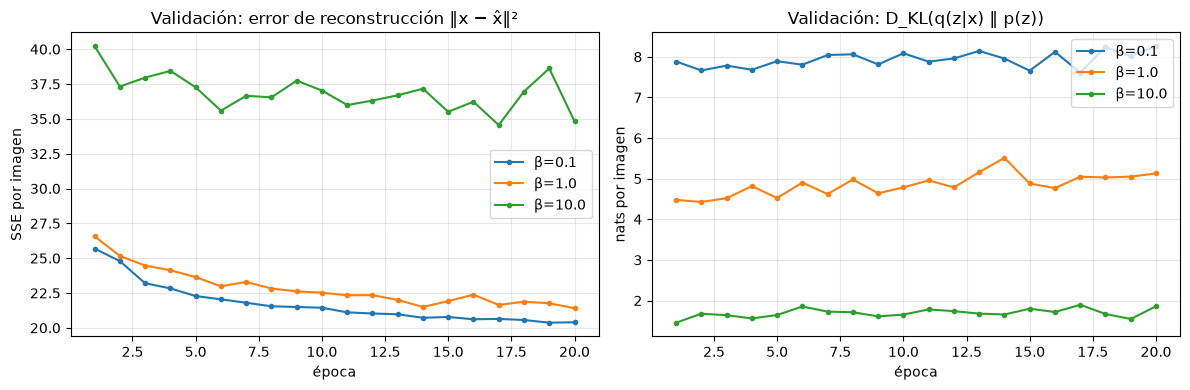

In [5]:
# Curvas de validación: error de reconstrucción y KL por época, para cada beta
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep_axis = np.arange(1, epochs + 1)
for beta in beta_values:
    ax[0].plot(ep_axis, hists[beta]["val_recon"], marker="o", ms=3, label=f"β={beta}")
    ax[1].plot(ep_axis, hists[beta]["val_kl"], marker="o", ms=3, label=f"β={beta}")
ax[0].set(title="Validación: error de reconstrucción ‖x − x̂‖²", xlabel="época", ylabel="SSE por imagen")
ax[1].set(title="Validación: D_KL(q(z|x) ‖ p(z))", xlabel="época", ylabel="nats por imagen")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig("figures/t1_2_curvas_validacion.png", dpi=150); plt.show()

## Task 1.3 – Figuras
### (a) Dispersión de $\mu$ para las 5 000 imágenes de validación

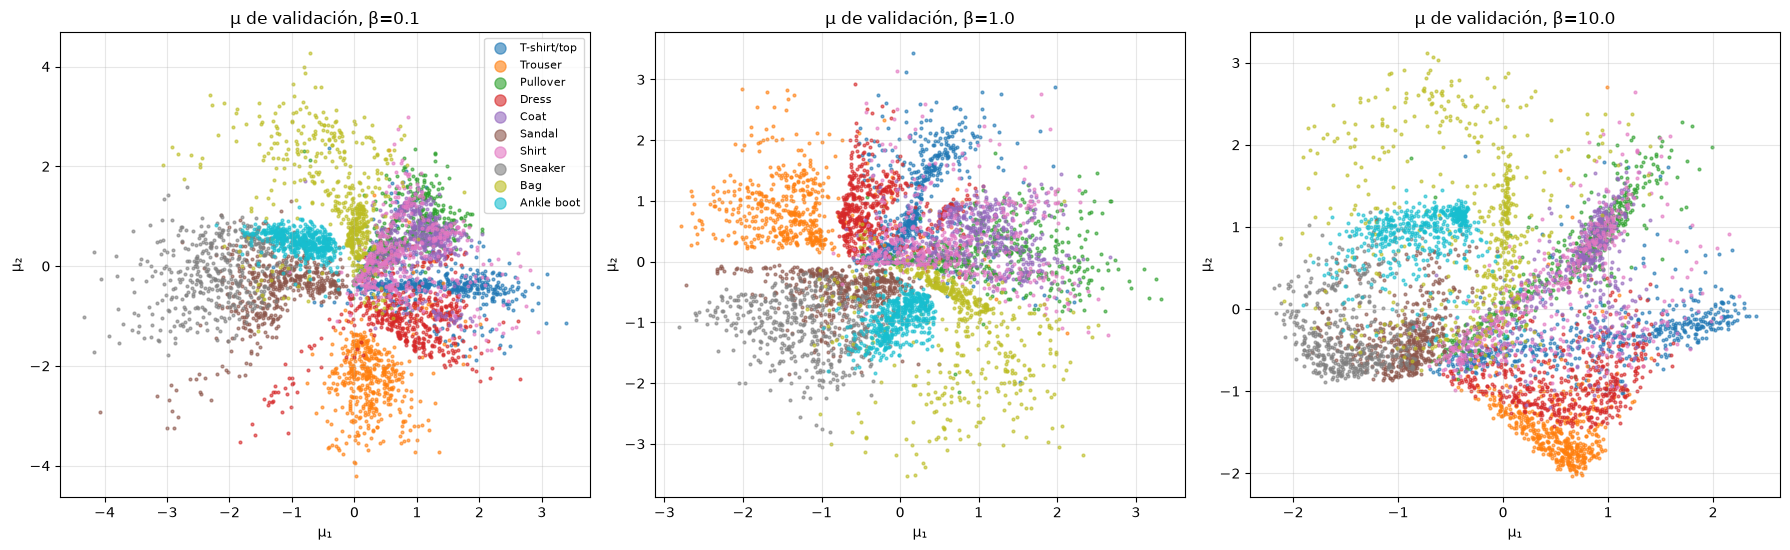

beta=0.1: rango mu1=[-4.32,3.38] mu2=[-4.20,4.26]  std(mu)=[1.214 1.145]  sigma media=[0.023 0.024]
beta=1.0: rango mu1=[-2.81,3.32] mu2=[-3.53,3.43]  std(mu)=[1.013 0.968]  sigma media=[0.087 0.092]
beta=10.0: rango mu1=[-2.18,2.41] mu2=[-2.03,3.11]  std(mu)=[0.941 0.949]  sigma media=[0.391 0.476]


In [6]:
@torch.no_grad()
def encode_all(model, X, bs=1000):
    model.eval(); mus, lvs = [], []
    for i in range(0, len(X), bs):
        m, l = model.encode(X[i:i + bs]); mus.append(m); lvs.append(l)
    return torch.cat(mus), torch.cat(lvs)

mus_val = {b: encode_all(vaes[b], X_val) for b in beta_values}
y_np = Y_val.cpu().numpy()
cmap = plt.get_cmap("tab10")

fig, ax = plt.subplots(1, 3, figsize=(18, 5.6))
for a, beta in zip(ax, beta_values):
    m = mus_val[beta][0].cpu().numpy()
    for c in range(10):
        s = y_np == c
        a.scatter(m[s, 0], m[s, 1], s=4, alpha=.6, color=cmap(c), label=CLASSES[c])
    a.set(title=f"μ de validación, β={beta}", xlabel="μ₁", ylabel="μ₂"); a.grid(alpha=.3)
ax[0].legend(markerscale=4, fontsize=8, loc="best")
plt.tight_layout(); plt.savefig("figures/t1_3a_dispersion_mu.png", dpi=150); plt.show()

for beta in beta_values:
    m, lv = mus_val[beta]
    print(f"beta={beta}: rango mu1=[{m[:,0].min():.2f},{m[:,0].max():.2f}] "
          f"mu2=[{m[:,1].min():.2f},{m[:,1].max():.2f}]  std(mu)={m.std(0).cpu().numpy().round(3)}  "
          f"sigma media={lv.mul(.5).exp().mean(0).cpu().numpy().round(3)}")

### (b) Decodificación de una cuadrícula $15\times15$ de $z\in[-3,3]^2$ ($\beta=1$)

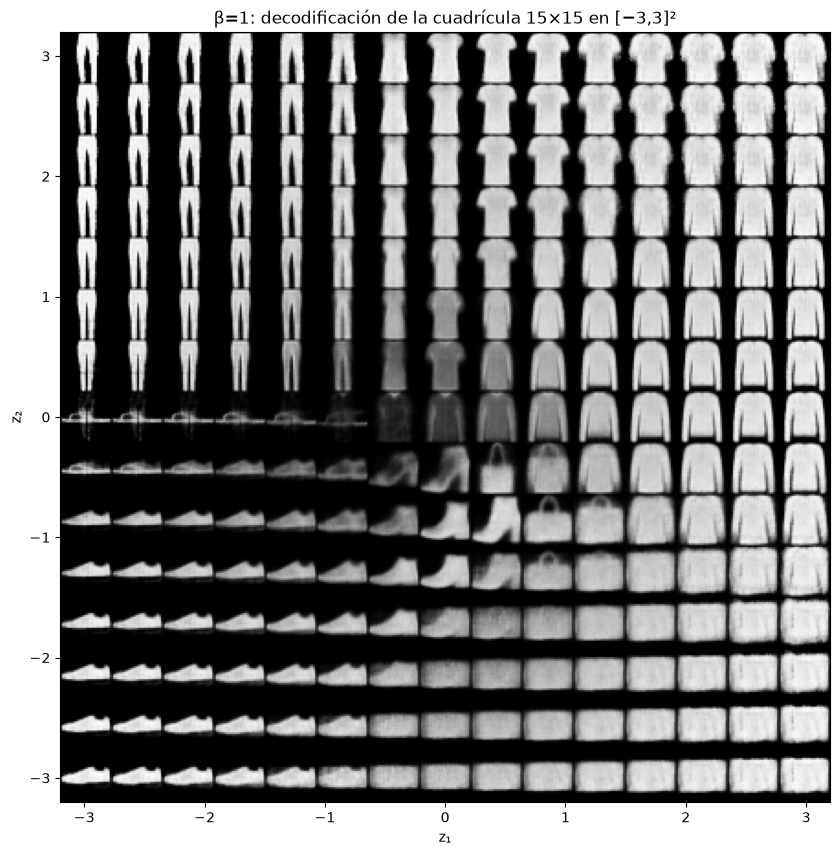

In [7]:
def show_grid(imgs, nrow, path=None, title=None, figsize=None, vmin=0, vmax=1):
    # imgs: (N,1,28,28) -> mosaico de nrow columnas
    imgs = imgs.detach().cpu().squeeze(1).numpy()
    N = len(imgs); ncol = math.ceil(N / nrow)
    canvas = np.ones((ncol * 28, nrow * 28)) * vmin
    for k in range(N):
        r, c = divmod(k, nrow); canvas[r*28:(r+1)*28, c*28:(c+1)*28] = imgs[k]
    plt.figure(figsize=figsize or (nrow * .6, ncol * .6))
    plt.imshow(canvas, cmap="gray", vmin=vmin, vmax=vmax); plt.axis("off")
    if title: plt.title(title)
    if path: plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

g = torch.linspace(-3, 3, 15)
# fila r corresponde a z2 (de +3 arriba a -3 abajo), columna c a z1 (de -3 a +3)
Z_grid = torch.stack([torch.stack([g[c], g.flip(0)[r]]) for r in range(15) for c in range(15)]).to(device)
with torch.no_grad():
    vaes[1.0].eval(); grid_imgs = vaes[1.0].decode(Z_grid)

fig, ax = plt.subplots(figsize=(10, 10))
canvas = grid_imgs.cpu().squeeze(1).numpy().reshape(15, 15, 28, 28).transpose(0, 2, 1, 3).reshape(15*28, 15*28)
ax.imshow(canvas, cmap="gray", extent=[-3.2, 3.2, -3.2, 3.2])
ax.set(title="β=1: decodificación de la cuadrícula 15×15 en [−3,3]²", xlabel="z₁", ylabel="z₂")
plt.savefig("figures/t1_3b_cuadricula_beta1.png", dpi=150, bbox_inches="tight"); plt.show()

### (c) 64 muestras $z\sim\mathcal N(0,I)$ para cada $\beta$

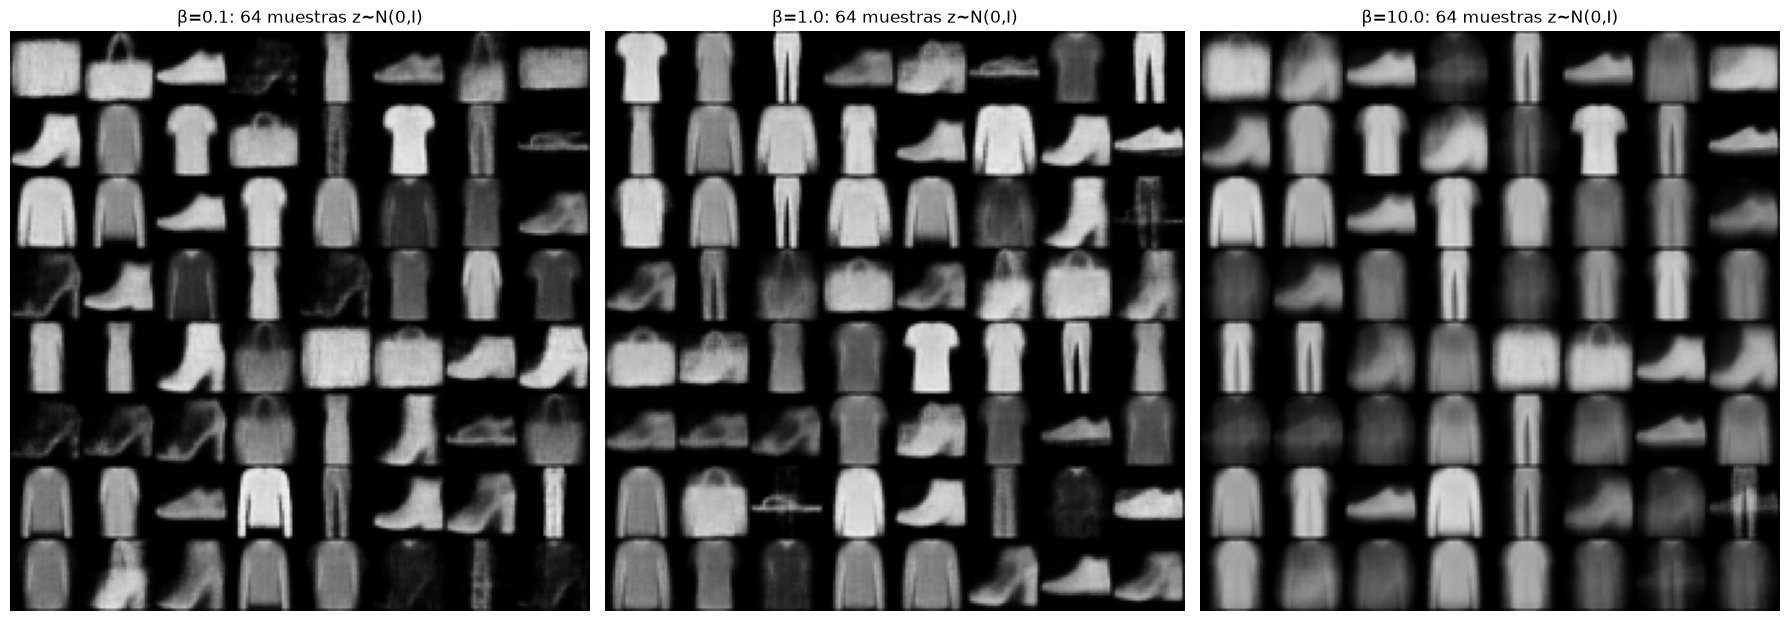

In [8]:
set_seed(SEED)
z64 = torch.randn(64, latent_dim, device=device)   # los mismos z para los tres modelos
fig, ax = plt.subplots(1, 3, figsize=(18, 6.3))
for a, beta in zip(ax, beta_values):
    with torch.no_grad():
        vaes[beta].eval(); s = vaes[beta].decode(z64).cpu().squeeze(1).numpy()
    canvas = s.reshape(8, 8, 28, 28).transpose(0, 2, 1, 3).reshape(8*28, 8*28)
    a.imshow(canvas, cmap="gray", vmin=0, vmax=1); a.axis("off"); a.set_title(f"β={beta}: 64 muestras z~N(0,I)")
plt.tight_layout(); plt.savefig("figures/t1_3c_muestras.png", dpi=150, bbox_inches="tight"); plt.show()

### (d) Interpolación en píxeles vs. en el espacio latente ($\beta=1$)
Se eligen dos imágenes de validación de clases distintas (Trouser y Ankle boot). Con 8 puntos intermedios
($\lambda=1/9,\dots,8/9$) más los extremos: en píxeles $x_\lambda=(1-\lambda)x_A+\lambda x_B$; en el latente
$\hat x_\lambda=\mathrm{dec}\big((1-\lambda)\mu_A+\lambda\mu_B\big)$.

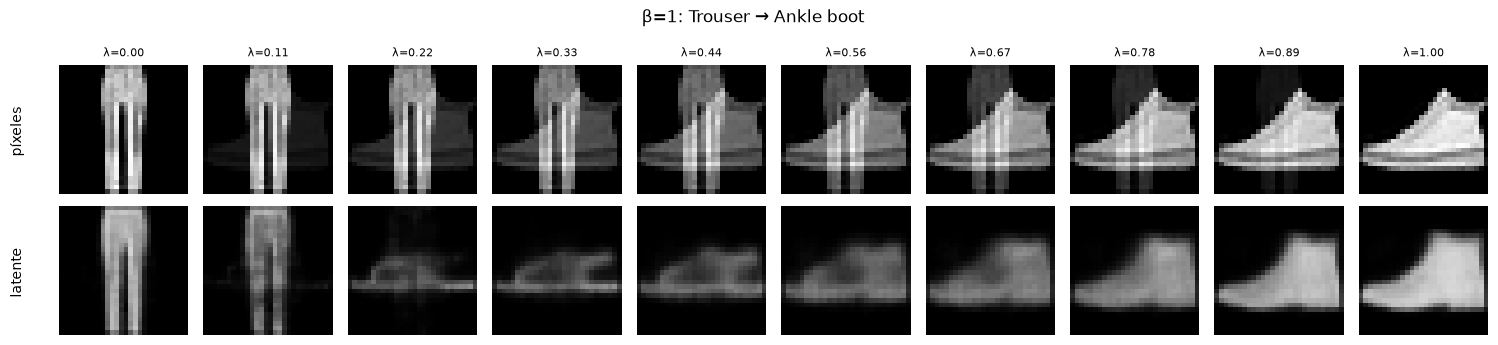

mu_A = [[-1.444  0.368]]  mu_B = [[-0.193 -1.305]]
trayectoria latente:
 [[-1.44  0.37]
 [-1.31  0.18]
 [-1.17 -0.  ]
 [-1.03 -0.19]
 [-0.89 -0.38]
 [-0.75 -0.56]
 [-0.61 -0.75]
 [-0.47 -0.93]
 [-0.33 -1.12]
 [-0.19 -1.31]]


In [9]:
cls_A, cls_B = 1, 9      # Trouser -> Ankle boot
idx_A = (Y_val == cls_A).nonzero()[0].item()
idx_B = (Y_val == cls_B).nonzero()[0].item()
xA, xB = X_val[idx_A:idx_A+1], X_val[idx_B:idx_B+1]
lams = torch.linspace(0, 1, 10, device=device).view(-1, 1, 1, 1)   # 0, 8 intermedios, 1

pix_interp = (1 - lams) * xA + lams * xB                               # interpolación en píxeles
with torch.no_grad():
    v = vaes[1.0].eval()
    muA, _ = v.encode(xA); muB, _ = v.encode(xB)
    z_path = (1 - lams.view(-1, 1)) * muA + lams.view(-1, 1) * muB      # interpolación latente
    lat_interp = v.decode(z_path)

fig, ax = plt.subplots(2, 10, figsize=(15, 3.6))
for k in range(10):
    ax[0, k].imshow(pix_interp[k, 0].cpu(), cmap="gray", vmin=0, vmax=1); ax[0, k].axis("off")
    ax[1, k].imshow(lat_interp[k, 0].cpu(), cmap="gray", vmin=0, vmax=1); ax[1, k].axis("off")
    ax[0, k].set_title(f"λ={lams[k].item():.2f}", fontsize=8)
ax[0, 0].text(-8, 14, "píxeles", rotation=90, va="center", ha="right")
ax[1, 0].text(-8, 14, "latente", rotation=90, va="center", ha="right")
plt.suptitle(f"β=1: {CLASSES[cls_A]} → {CLASSES[cls_B]}")
plt.tight_layout(); plt.savefig("figures/t1_3d_interpolacion.png", dpi=150, bbox_inches="tight"); plt.show()

print("mu_A =", muA.cpu().numpy().round(3), " mu_B =", muB.cpu().numpy().round(3))
print("trayectoria latente:\n", z_path.cpu().numpy().round(2))
RESULTS["interp"] = {"idx_A": idx_A, "idx_B": idx_B, "muA": muA.cpu().tolist()[0], "muB": muB.cpu().tolist()[0],
                     "z_path": z_path.cpu().tolist()}

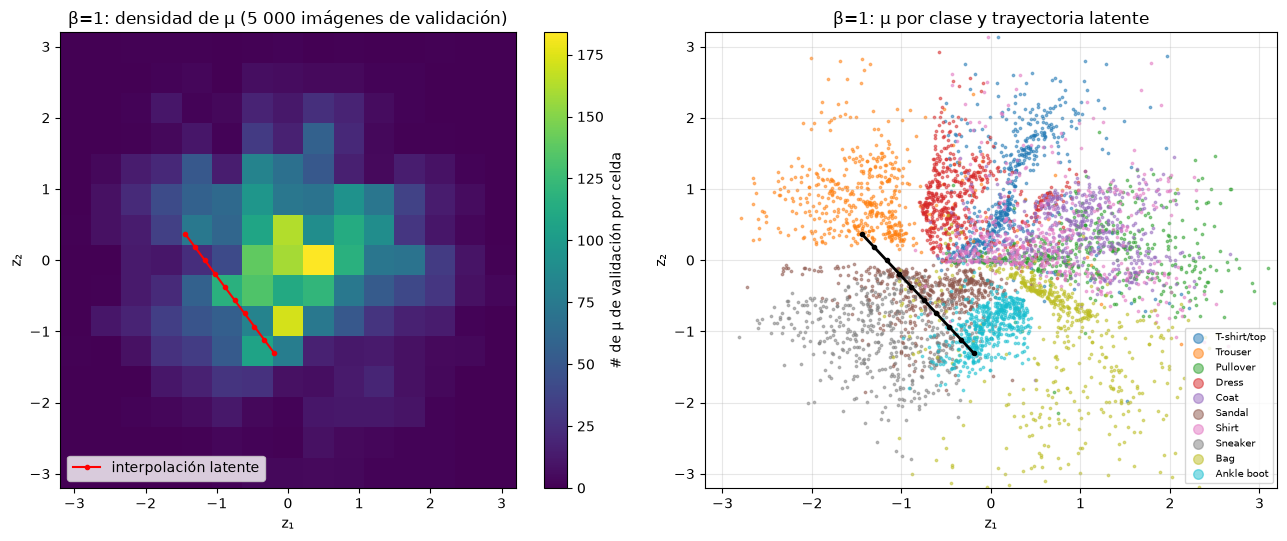

celdas de la cuadrícula 15x15 sin ningún mu de validación: 58/225
fracción de mu con ||mu||>2: 0.1448, >2.5: 0.0408


In [10]:
# Apoyo para 1.4(c): densidad de los mu de validación (beta=1) sobre la misma cuadrícula, y
# trayectoria de la interpolación latente superpuesta, para ubicar zonas vacías del latente.
m1 = mus_val[1.0][0].cpu().numpy()
H, xe, ye = np.histogram2d(m1[:, 0], m1[:, 1], bins=15, range=[[-3.2, 3.2], [-3.2, 3.2]])
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
im = ax[0].imshow(H.T[::-1], extent=[-3.2, 3.2, -3.2, 3.2], cmap="viridis")
plt.colorbar(im, ax=ax[0], label="# de μ de validación por celda")
zp = np.array(RESULTS["interp"]["z_path"])
ax[0].plot(zp[:, 0], zp[:, 1], "r.-", label="interpolación latente"); ax[0].legend(loc="lower left")
ax[0].set(title="β=1: densidad de μ (5 000 imágenes de validación)", xlabel="z₁", ylabel="z₂")
for c in range(10):
    s = y_np == c
    ax[1].scatter(m1[s, 0], m1[s, 1], s=3, alpha=.5, color=cmap(c), label=CLASSES[c])
ax[1].plot(zp[:, 0], zp[:, 1], "k.-", lw=2)
ax[1].set(xlim=(-3.2, 3.2), ylim=(-3.2, 3.2), title="β=1: μ por clase y trayectoria latente", xlabel="z₁", ylabel="z₂")
ax[1].legend(markerscale=4, fontsize=7); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("figures/t1_4c_densidad_latente.png", dpi=150, bbox_inches="tight"); plt.show()

empty = (H == 0).sum(); print(f"celdas de la cuadrícula 15x15 sin ningún mu de validación: {empty}/225")
r = np.sqrt((m1**2).sum(1)); print(f"fracción de mu con ||mu||>2: {(r>2).mean():.4f}, >2.5: {(r>2.5).mean():.4f}")
RESULTS["latent_density"] = {"empty_cells": int(empty), "frac_r_gt2": float((r>2).mean()),
                             "frac_r_gt25": float((r>2.5).mean()),
                             "max_abs_mu": np.abs(m1).max(0).tolist()}

## Task 1.4 – Análisis
### (a) Tabla final de reconstrucción y KL (en nats y en bits)

In [11]:
LN2 = math.log(2)
table = []
print(f"{'beta':>5} | {'recon (SSE)':>11} | {'KL (nats)':>9} | {'KL (bits)':>9} | bits vs log2(10)={math.log2(10):.2f}")
for beta in beta_values:
    r, k = hists[beta]["val_recon"][-1], hists[beta]["val_kl"][-1]
    table.append({"beta": beta, "recon": r, "kl_nats": k, "kl_bits": k / LN2})
    print(f"{beta:>5} | {r:11.3f} | {k:9.3f} | {k/LN2:9.3f} | {'>' if k/LN2 > math.log2(10) else '<'} 3.32")
RESULTS["t1_4a"] = table

# Apoyo: separabilidad de clases en el código latente (kNN sobre mu con k=15, entrenado en train)
@torch.no_grad()
def knn_acc(beta, k=15):
    mtr, _ = encode_all(vaes[beta], X_train); mva = mus_val[beta][0]
    d = torch.cdist(mva, mtr); nn_idx = d.topk(k, largest=False).indices
    pred = torch.mode(Y_train[nn_idx], dim=1).values
    return (pred == Y_val).float().mean().item()
knn = {b: knn_acc(b) for b in beta_values}
print("exactitud kNN (k=15) de la clase a partir de mu:", knn)
RESULTS["knn_mu"] = {str(b): v for b, v in knn.items()}

 beta | recon (SSE) | KL (nats) | KL (bits) | bits vs log2(10)=3.32
  0.1 |      20.401 |     8.261 |    11.919 | > 3.32
  1.0 |      21.413 |     5.128 |     7.398 | > 3.32
 10.0 |      34.829 |     1.858 |     2.680 | < 3.32


exactitud kNN (k=15) de la clase a partir de mu: {0.1: 0.7184000015258789, 1.0: 0.7173999547958374, 10.0: 0.6421999931335449}


### (b) Verificación Monte Carlo de la KL
$\widehat{KL}=\frac1N\sum_{i}\left[\log q(z_i)-\log p(z_i)\right]$, con $z_i\sim q(z\mid x)$, $N=10^5$ y
$\log\mathcal N(z;\mu,\sigma^2)=-\tfrac12\sum_j\left[\log(2\pi)+\log\sigma_j^2+(z_j-\mu_j)^2/\sigma_j^2\right]$ escrita a mano.

In [12]:
def log_normal_diag(z, mu, logvar):
    # log N(z; mu, diag sigma^2) = -1/2 * sum_j [ log(2 pi) + log sigma_j^2 + (z_j - mu_j)^2 / sigma_j^2 ]
    return -0.5 * torch.sum(math.log(2 * math.pi) + logvar + (z - mu).pow(2) / logvar.exp(), dim=-1)

set_seed(SEED)
idx_mc = 0                                   # primera imagen de validación
with torch.no_grad():
    mu_mc, lv_mc = vaes[1.0].eval().encode(X_val[idx_mc:idx_mc+1])
mu_mc, lv_mc = mu_mc.double(), lv_mc.double()
N_MC = 100_000
z = mu_mc + lv_mc.mul(.5).exp() * torch.randn(N_MC, latent_dim, device=device, dtype=torch.float64)  # z ~ q(z|x)
log_q = log_normal_diag(z, mu_mc, lv_mc)
log_p = log_normal_diag(z, torch.zeros_like(mu_mc), torch.zeros_like(lv_mc))   # p(z) = N(0, I)
terms = log_q - log_p
kl_mc = terms.mean().item()
se_mc = (terms.std() / math.sqrt(N_MC)).item()        # error estándar del promedio Monte Carlo
kl_cf = kl_closed_form(mu_mc, lv_mc).item()
rel = abs(kl_mc - kl_cf) / kl_cf
print(f"clase={CLASSES[Y_val[idx_mc]]}  mu={mu_mc.cpu().numpy().round(4)}  sigma={lv_mc.mul(.5).exp().cpu().numpy().round(4)}")
print(f"KL forma cerrada = {kl_cf:.5f} nats")
print(f"KL Monte Carlo   = {kl_mc:.5f} nats  (desv. estándar de los términos = {terms.std().item():.4f})")
print(f"error estándar MC = {se_mc:.5f}   |error| = {abs(kl_mc-kl_cf):.5f} = {abs(kl_mc-kl_cf)/se_mc:.2f} errores estándar")
print(f"error relativo = {100*rel:.3f}%   (error relativo esperado ~ SE/KL = {100*se_mc/kl_cf:.3f}%)")
# Var teórica de log q - log p para gaussianas diagonales (para contrastar con la empírica)
s2 = lv_mc.exp()
var_th = torch.sum(0.5 * (1 - s2).pow(2) + s2 * mu_mc.pow(2)).item()
print(f"desv. estándar teórica de los términos = {math.sqrt(var_th):.4f}")
RESULTS["t1_4b"] = {"idx": idx_mc, "class": CLASSES[Y_val[idx_mc]], "mu": mu_mc.cpu().tolist()[0],
                    "sigma": lv_mc.mul(.5).exp().cpu().tolist()[0], "kl_cf": kl_cf, "kl_mc": kl_mc,
                    "se": se_mc, "term_std": terms.std().item(), "term_std_theory": math.sqrt(var_th),
                    "rel_err": rel, "n_se": abs(kl_mc-kl_cf)/se_mc}

clase=T-shirt/top  mu=[[1.5629 1.3127]]  sigma=[[0.1205 0.1266]]
KL forma cerrada = 5.28078 nats
KL Monte Carlo   = 5.28560 nats  (desv. estándar de los términos = 1.0065)
error estándar MC = 0.00318   |error| = 0.00482 = 1.51 errores estándar
error relativo = 0.091%   (error relativo esperado ~ SE/KL = 0.060%)
desv. estándar teórica de los términos = 1.0163


### (c) Regiones no reconocibles y puntos medios de las interpolaciones

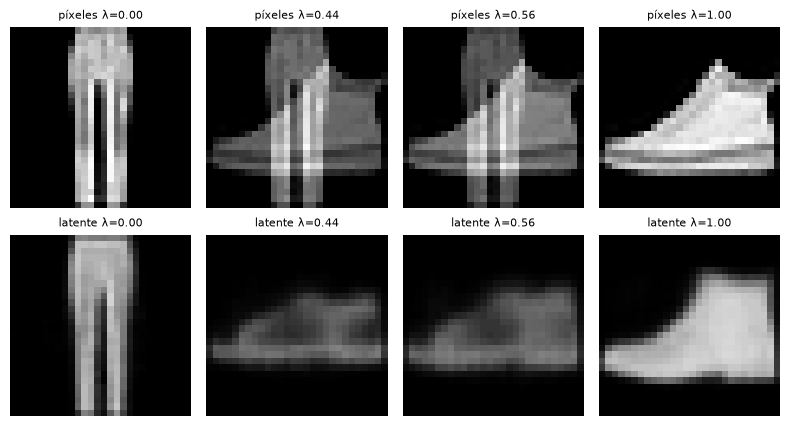

fracción de píxeles con intensidad intermedia: {'pix_mid': 0.403, 'lat_mid': 0.27, 'real_A': 0.078, 'real_B': 0.097}


In [13]:
# Zoom a los puntos medios (lambda = 4/9 y 5/9) de ambas interpolaciones, y la imagen decodificada de cada extremo
fig, ax = plt.subplots(2, 4, figsize=(8, 4.4))
for j, k in enumerate([0, 4, 5, 9]):
    ax[0, j].imshow(pix_interp[k, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax[1, j].imshow(lat_interp[k, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax[0, j].set_title(f"píxeles λ={lams[k].item():.2f}", fontsize=8); ax[1, j].set_title(f"latente λ={lams[k].item():.2f}", fontsize=8)
    ax[0, j].axis("off"); ax[1, j].axis("off")
plt.tight_layout(); plt.savefig("figures/t1_4c_puntos_medios.png", dpi=150, bbox_inches="tight"); plt.show()

# Cuantificación: la imagen del punto medio en píxeles tiene "dos siluetas"; medimos la fracción de píxeles
# con intensidad intermedia (0.2 < x < 0.6), típica de la superposición semitransparente.
def frac_mid(x): return ((x > 0.2) & (x < 0.6)).float().mean().item()
mid = {"pix_mid": frac_mid(pix_interp[4:6]), "lat_mid": frac_mid(lat_interp[4:6]),
       "real_A": frac_mid(xA), "real_B": frac_mid(xB)}
print("fracción de píxeles con intensidad intermedia:", {k: round(v, 3) for k, v in mid.items()})
RESULTS["t1_4c"] = mid

### (d) Nitidez
Nitidez $=\frac{1}{N\cdot 28\cdot 27}\sum_{n,i,j}\lvert x_{n,i,j+1}-x_{n,i,j}\rvert$ (diferencia entre píxeles horizontalmente adyacentes).
Se compara con 1 000 imágenes reales de validación y 1 000 generadas ($z\sim\mathcal N(0,I)$, salida $\hat x$ del decoder) por cada $\beta$.

In [14]:
def sharpness(x):
    # magnitud media de la diferencia entre píxeles horizontalmente adyacentes
    return (x[..., :, 1:] - x[..., :, :-1]).abs().mean().item()

set_seed(SEED)
sharp = {"real": sharpness(X_val[:1000])}
z1000 = torch.randn(1000, latent_dim, device=device)
with torch.no_grad():
    for beta in beta_values:
        sharp[f"beta={beta}"] = sharpness(vaes[beta].eval().decode(z1000))
for k, v in sharp.items(): print(f"{k:>10}: {v:.4f}   ({100*v/sharp['real']:.1f}% de la real)")
# varianza de decoder implícita sigma_x^2 = beta/2  ->  desviación estándar en unidades de píxel [0,1]
for beta in beta_values: print(f"beta={beta}: sigma_x^2 = {beta/2:.3f}, sigma_x = {math.sqrt(beta/2):.3f}")
RESULTS["t1_4d"] = sharp

      real: 0.0891   (100.0% de la real)
  beta=0.1: 0.0472   (52.9% de la real)
  beta=1.0: 0.0516   (57.9% de la real)
 beta=10.0: 0.0438   (49.1% de la real)
beta=0.1: sigma_x^2 = 0.050, sigma_x = 0.224
beta=1.0: sigma_x^2 = 0.500, sigma_x = 0.707
beta=10.0: sigma_x^2 = 5.000, sigma_x = 2.236


# Task 2

## Task 2.1 – Calendario lineal y fórmula cerrada
Datos escalados a $[-1,1]$ ($x\mapsto 2x-1$). Convención de índices: el tensor `betas[t-1]` guarda $\beta_t$ para
$t=1,\dots,T$, de modo que `alpha_bar[t-1]` $=\bar\alpha_t=\prod_{s=1}^t\alpha_s$.

In [15]:
T          = 1000
beta_start = 1e-4
beta_end   = 0.02

# Calendario lineal: beta_t = beta_start + (t-1)/(T-1) * (beta_end - beta_start),  t = 1..T
t_axis = torch.arange(1, T + 1, dtype=torch.float64)
betas = beta_start + (t_axis - 1) / (T - 1) * (beta_end - beta_start)
alphas = 1.0 - betas                         # alpha_t = 1 - beta_t
alpha_bar = torch.cumprod(alphas, dim=0)     # alpha_bar_t = prod_{s<=t} alpha_s
print("beta_1 =", betas[0].item(), " beta_T =", betas[-1].item(), " alpha_bar_T =", alpha_bar[-1].item())

betas_d, alpha_bar_d = betas.float().to(device), alpha_bar.float().to(device)

def q_sample(x0, t, eps, alpha_bar=alpha_bar_d):
    # Fórmula cerrada del forward:  x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps
    # x0: (B,1,28,28), t: (B,) enteros en {1..T}, eps: (B,1,28,28) ~ N(0, I)
    ab = alpha_bar[t - 1].view(-1, 1, 1, 1)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps

# datos en [-1, 1]
X_train_d = X_train * 2 - 1
X_val_d   = X_val * 2 - 1
print(X_train_d.min().item(), X_train_d.max().item())

beta_1 = 0.0001  beta_T = 0.02  alpha_bar_T = 4.0358297653756754e-05
-1.0 1.0


## Task 2.2 – Verificación empírica de la fórmula cerrada
Se aplica el proceso **paso a paso** $x_s=\sqrt{\alpha_s}\,x_{s-1}+\sqrt{\beta_s}\,\epsilon_s$ a 5 000 copias de una imagen
durante 300 pasos y se compara con $\mathbb E[x_{300}]=\sqrt{\bar\alpha_{300}}\,x_0$ y $\mathrm{Var}[x_{300}]=1-\bar\alpha_{300}$.

alpha_bar_300 = 0.396420, sqrt = 0.629619, 1 - alpha_bar_300 = 0.603580


error máximo absoluto de la media = 0.03578   error medio = 0.00894
varianza empírica promedio = 0.603569  vs teórica 0.603580  (rango por píxel [0.5702, 0.6440])
error estándar de la media = 0.01099;  max|err|/SE = 3.26
fracción de píxeles con |err| < 1.96 SE = 0.9452  (esperado 0.95)
desv. estándar de los z-scores = 1.0234 (esperado 1)
mediana esperada de max|z| sobre 784 píxeles ≈ 3.33 SE = 0.03653


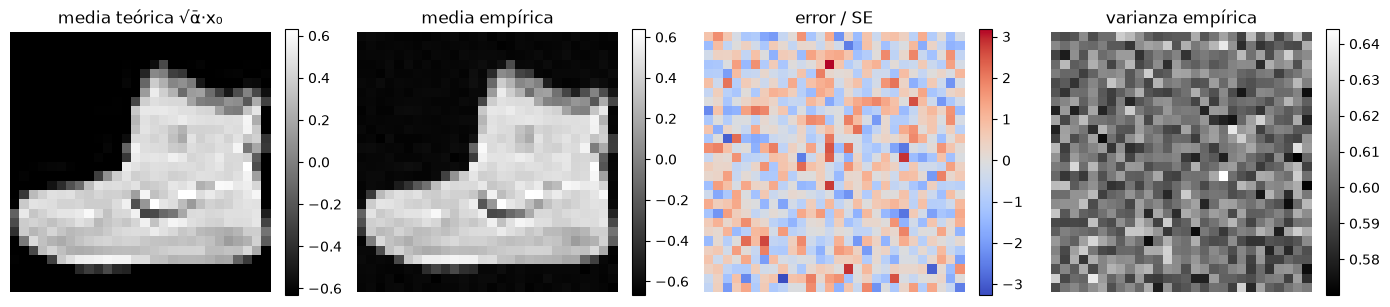

In [16]:
set_seed(SEED)
t_chk, n_copies = 300, 5000
x0_fix = X_train_d[0]                                         # imagen fija
x = x0_fix.unsqueeze(0).repeat(n_copies, 1, 1, 1).double()     # 5 000 copias
a64, b64 = alphas.to(device), betas.to(device)
for s in range(1, t_chk + 1):
    # paso de la cadena de Markov q(x_s | x_{s-1}) = N( sqrt(alpha_s) x_{s-1}, beta_s I ), ruido independiente
    x = a64[s-1].sqrt() * x + b64[s-1].sqrt() * torch.randn_like(x)

ab300 = alpha_bar[t_chk - 1].item()
mean_emp, var_emp = x.mean(0), x.var(0)                       # por píxel (varianza insesgada)
mean_th, var_th = math.sqrt(ab300) * x0_fix.double(), 1 - ab300
err_mean = (mean_emp - mean_th).abs()
se_mean = math.sqrt(var_th / n_copies)                        # error estándar de un promedio de 5 000
se_var = var_th * math.sqrt(2 / (n_copies - 1))               # error estándar de la varianza muestral (gaussiana)
z_scores = ((mean_emp - mean_th) / se_mean).flatten()

print(f"alpha_bar_300 = {ab300:.6f}, sqrt = {math.sqrt(ab300):.6f}, 1 - alpha_bar_300 = {var_th:.6f}")
print(f"error máximo absoluto de la media = {err_mean.max().item():.5f}   error medio = {err_mean.mean().item():.5f}")
print(f"varianza empírica promedio = {var_emp.mean().item():.6f}  vs teórica {var_th:.6f}  "
      f"(rango por píxel [{var_emp.min().item():.4f}, {var_emp.max().item():.4f}])")
print(f"error estándar de la media = {se_mean:.5f};  max|err|/SE = {err_mean.max().item()/se_mean:.2f}")
print(f"fracción de píxeles con |err| < 1.96 SE = {(z_scores.abs() < 1.96).double().mean().item():.4f}  (esperado 0.95)")
print(f"desv. estándar de los z-scores = {z_scores.std().item():.4f} (esperado 1)")
# Máximo esperado de |N(0,1)| sobre 784 píxeles independientes: mediana de la distribución del máximo
# P(max|z| <= m) = (2Phi(m)-1)^784 = 0.5  ->  m = Phi^{-1}((0.5^(1/784) + 1) / 2)
q50 = torch.special.ndtri(torch.tensor((0.5 ** (1 / 784) + 1) / 2, dtype=torch.float64)).item()
print(f"mediana esperada de max|z| sobre 784 píxeles ≈ {q50:.2f} SE = {q50*se_mean:.5f}")
RESULTS["t2_2"] = {"ab300": ab300, "max_err_mean": err_mean.max().item(), "mean_err_mean": err_mean.mean().item(),
                   "var_emp_mean": var_emp.mean().item(), "var_emp_min": var_emp.min().item(),
                   "var_emp_max": var_emp.max().item(), "var_th": var_th, "se_mean": se_mean, "se_var": se_var,
                   "max_over_se": err_mean.max().item()/se_mean,
                   "frac_within_196": (z_scores.abs() < 1.96).double().mean().item(),
                   "z_std": z_scores.std().item(), "expected_max_z": q50}

fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
for a, img, ttl in zip(ax, [mean_th, mean_emp, (mean_emp - mean_th) / se_mean, var_emp],
                       ["media teórica √ᾱ·x₀", "media empírica", "error / SE", "varianza empírica"]):
    im = a.imshow(img[0].cpu(), cmap="gray" if "error" not in ttl else "coolwarm"); a.set_title(ttl); a.axis("off")
    plt.colorbar(im, ax=a, fraction=.046)
plt.tight_layout(); plt.savefig("figures/t2_2_verificacion.png", dpi=150, bbox_inches="tight"); plt.show()

## Task 2.3 – Visualización, $\bar\alpha_t$ y SNR

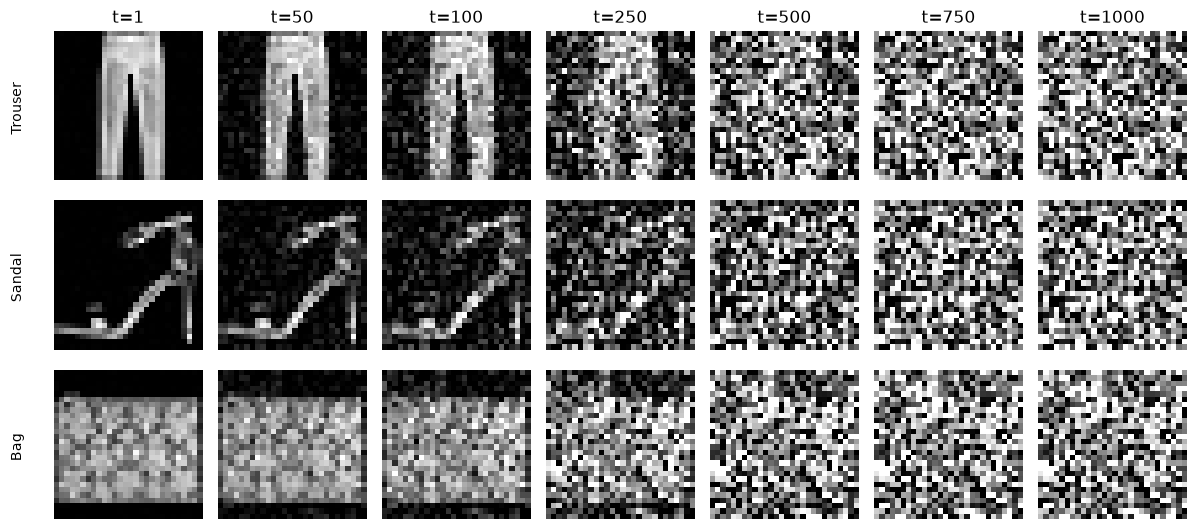

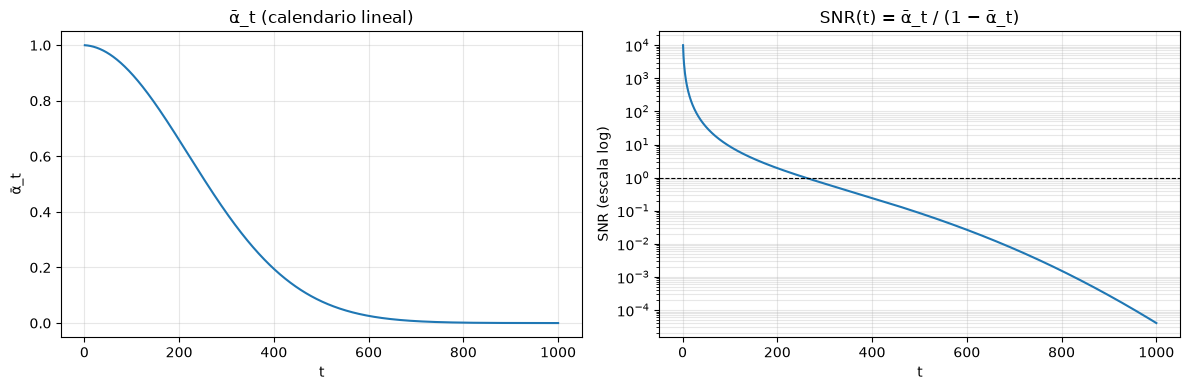

primer t con SNR(t) < 1: 260  (SNR=0.9905, SNR(t-1)=1.0010)
primer t con alpha_bar_t < 0.01: 674  (alpha_bar=0.00999)
SNR(1) = 9999.0, SNR(T) = 4.036e-05


In [17]:
ts_show = [1, 50, 100, 250, 500, 750, 1000]
cls_show = [1, 5, 8]     # Trouser, Sandal, Bag
set_seed(SEED)
fig, ax = plt.subplots(3, len(ts_show), figsize=(12, 5.5))
for r, c in enumerate(cls_show):
    x0 = X_train_d[(Y_train == c).nonzero()[0].item()].unsqueeze(0)
    eps = torch.randn_like(x0)                          # mismo ruido para todos los t de la fila
    for k, t in enumerate(ts_show):
        xt = q_sample(x0, torch.tensor([t], device=device), eps)
        ax[r, k].imshow(xt[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1); ax[r, k].axis("off")
        if r == 0: ax[r, k].set_title(f"t={t}")
    ax[r, 0].text(-6, 14, CLASSES[c], rotation=90, va="center", ha="right")
plt.tight_layout(); plt.savefig("figures/t2_3a_forward.png", dpi=150, bbox_inches="tight"); plt.show()

snr = alpha_bar / (1 - alpha_bar)                       # SNR(t) = alpha_bar_t / (1 - alpha_bar_t)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t_axis, alpha_bar); ax[0].set(title="ᾱ_t (calendario lineal)", xlabel="t", ylabel="ᾱ_t"); ax[0].grid(alpha=.3)
ax[1].semilogy(t_axis, snr); ax[1].axhline(1, color="k", ls="--", lw=.8)
ax[1].set(title="SNR(t) = ᾱ_t / (1 − ᾱ_t)", xlabel="t", ylabel="SNR (escala log)"); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.savefig("figures/t2_3b_alphabar_snr.png", dpi=150, bbox_inches="tight"); plt.show()

def first_t(mask): return int(torch.nonzero(mask)[0].item()) + 1     # índice -> t (1-based)
t_snr1 = first_t(snr < 1); t_ab001 = first_t(alpha_bar < 0.01)
print(f"primer t con SNR(t) < 1: {t_snr1}  (SNR={snr[t_snr1-1]:.4f}, SNR(t-1)={snr[t_snr1-2]:.4f})")
print(f"primer t con alpha_bar_t < 0.01: {t_ab001}  (alpha_bar={alpha_bar[t_ab001-1]:.5f})")
print(f"SNR(1) = {snr[0]:.1f}, SNR(T) = {snr[-1]:.3e}")
RESULTS["t2_3"] = {"t_snr1": t_snr1, "t_ab001": t_ab001, "snr_1": snr[0].item(), "snr_T": snr[-1].item(),
                   "ab_T": alpha_bar[-1].item()}

## Task 2.4 – Calendario propio: coseno truncado
Se parte del calendario coseno de **Nichol & Dhariwal (2021), *Improved Denoising Diffusion Probabilistic Models*, ICML**:
$\bar\alpha_t=f(t)/f(0)$, $f(t)=\cos^2\!\left(\frac{t/T+s}{1+s}\cdot\frac{\pi}{2}\right)$, $s=0.008$.
En el original $\bar\alpha_T=0$ exactamente, por lo que $\beta_T=1$ y los autores deben recortar $\beta_t\le0.999$.

**Modificación:** se multiplica el argumento por un factor $\tau<1$,
$f_\tau(t)=\cos^2\!\left(\tau\cdot\frac{t/T+s}{1+s}\cdot\frac{\pi}{2}\right)$, y se elige $\tau$ (por bisección) para que
$\bar\alpha_T=10^{-4}$ exactamente. Así $\bar\alpha_T<10^{-3}$, todas las $\beta_t=1-\bar\alpha_t/\bar\alpha_{t-1}$ están en $(0,1)$
sin necesidad de recortes, y se conserva la forma coseno (log-SNR casi lineal en la zona media).

tau = 0.993634
beta_t en [4.076e-05, 0.2502]
lineal : alpha_bar_T = 4.036e-05, primer t con SNR<1 = 260
coseno : alpha_bar_T = 1.000e-04, primer t con SNR<1 = 500


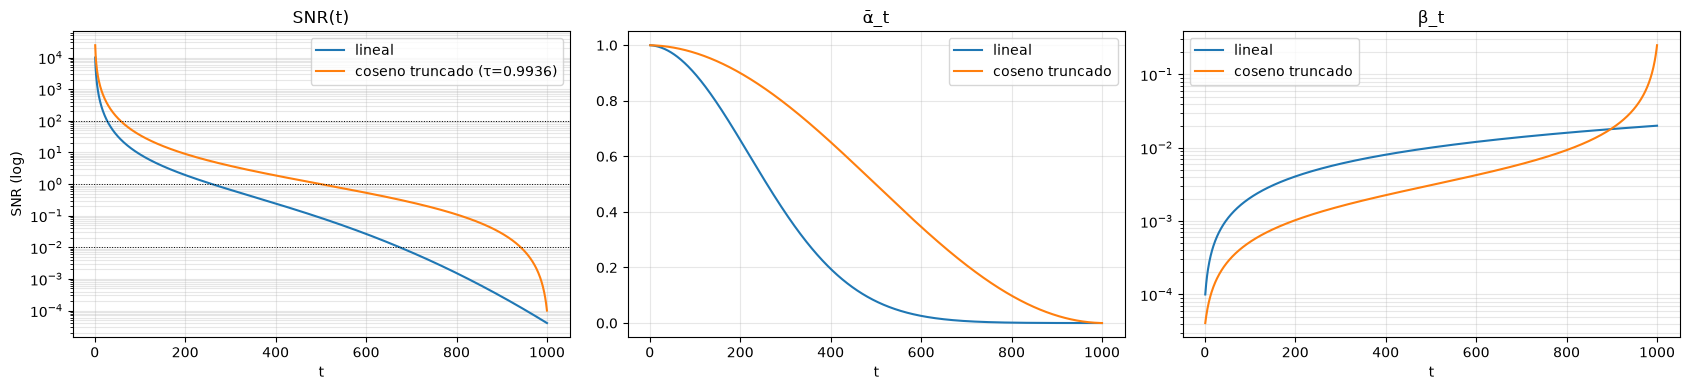

In [18]:
s_cos, target_abT = 0.008, 1e-4

def cosine_trunc_alpha_bar(tau, T=T, s=s_cos):
    t = torch.arange(0, T + 1, dtype=torch.float64)
    f = torch.cos(tau * (t / T + s) / (1 + s) * math.pi / 2) ** 2
    return f[1:] / f[0]                              # alpha_bar_t para t = 1..T

lo, hi = 0.9, 1.0                                    # bisección sobre tau para alpha_bar_T = 1e-4
for _ in range(100):
    mid = (lo + hi) / 2
    if cosine_trunc_alpha_bar(mid)[-1] > target_abT: lo = mid
    else: hi = mid
tau = (lo + hi) / 2
alpha_bar_c = cosine_trunc_alpha_bar(tau)
alpha_bar_c_prev = torch.cat([torch.ones(1, dtype=torch.float64), alpha_bar_c[:-1]])
betas_c = 1 - alpha_bar_c / alpha_bar_c_prev        # beta_t = 1 - alpha_bar_t / alpha_bar_{t-1}
snr_c = alpha_bar_c / (1 - alpha_bar_c)

assert (betas_c > 0).all() and (betas_c < 1).all() and alpha_bar_c[-1] < 1e-3
t_snr1_c = first_t(snr_c < 1)
print(f"tau = {tau:.6f}")
print(f"beta_t en [{betas_c.min():.3e}, {betas_c.max():.4f}]")
print(f"lineal : alpha_bar_T = {alpha_bar[-1]:.3e}, primer t con SNR<1 = {t_snr1}")
print(f"coseno : alpha_bar_T = {alpha_bar_c[-1]:.3e}, primer t con SNR<1 = {t_snr1_c}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].semilogy(t_axis, snr, label="lineal"); ax[0].semilogy(t_axis, snr_c, label=f"coseno truncado (τ={tau:.4f})")
for yv in [100, 1, 0.01]: ax[0].axhline(yv, color="k", ls=":", lw=.7)
ax[0].set(title="SNR(t)", xlabel="t", ylabel="SNR (log)"); ax[0].legend(); ax[0].grid(alpha=.3, which="both")
ax[1].plot(t_axis, alpha_bar, label="lineal"); ax[1].plot(t_axis, alpha_bar_c, label="coseno truncado")
ax[1].set(title="ᾱ_t", xlabel="t"); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].semilogy(t_axis, betas, label="lineal"); ax[2].semilogy(t_axis, betas_c, label="coseno truncado")
ax[2].set(title="β_t", xlabel="t"); ax[2].legend(); ax[2].grid(alpha=.3, which="both")
plt.tight_layout(); plt.savefig("figures/t2_4_calendarios.png", dpi=150, bbox_inches="tight"); plt.show()
RESULTS["t2_4"] = {"tau": tau, "ab_T_lin": alpha_bar[-1].item(), "ab_T_cos": alpha_bar_c[-1].item(),
                   "t_snr1_lin": t_snr1, "t_snr1_cos": t_snr1_c,
                   "beta_c_min": betas_c.min().item(), "beta_c_max": betas_c.max().item()}

## Task 2.5 – Análisis
### (a) Aproximación de $\bar\alpha_T$

In [19]:
# Cálculo "a mano" (fórmulas cerradas) frente al valor numérico
S1_hand = T * (beta_start + beta_end) / 2                                  # suma aritmética
S2_hand = T * (beta_end**2 + beta_end * beta_start + beta_start**2) / 3    # aproximación integral
log_ab_approx = -S1_hand - 0.5 * S2_hand
S1_num, S2_num = betas.sum().item(), (betas**2).sum().item()
log_ab_exact = torch.log(alphas).sum().item()
print(f"sum beta   : a mano {S1_hand:.6f}   numérico {S1_num:.6f}")
print(f"sum beta^2 : a mano {S2_hand:.6f}   numérico {S2_num:.6f}")
print(f"log alpha_bar_T: aprox {log_ab_approx:.6f}   exacto {log_ab_exact:.6f}")
print(f"alpha_bar_T:     aprox {math.exp(log_ab_approx):.4e}   código {alpha_bar[-1].item():.4e}   "
      f"error relativo {abs(math.exp(log_ab_approx)-alpha_bar[-1].item())/alpha_bar[-1].item()*100:.3f}%")
S3 = (betas**3).sum().item(); print(f"siguiente término omitido -1/3 sum beta^3 = {-S3/3:.6f}")
RESULTS["t2_5a"] = {"S1_hand": S1_hand, "S2_hand": S2_hand, "S1_num": S1_num, "S2_num": S2_num,
                    "log_approx": log_ab_approx, "log_exact": log_ab_exact, "ab_approx": math.exp(log_ab_approx),
                    "ab_code": alpha_bar[-1].item(), "third_term": -S3/3}

sum beta   : a mano 10.050000   numérico 10.050000
sum beta^2 : a mano 0.134003   numérico 0.134069
log alpha_bar_T: aprox -10.117002   exacto -10.117714
alpha_bar_T:     aprox 4.0387e-05   código 4.0358e-05   error relativo 0.071%
siguiente término omitido -1/3 sum beta^3 = -0.000671
